# GRUPO 5 Movilidad Urbana: Predicción de Demanda de Bicicletas

In [ ]:
from google.colab import drive
import pandas as pd

In [ ]:
from google.colab import drive
import pandas as pd

# 1. Montar Google Drive
# Esto te pedirá permisos de acceso a tu cuenta de Google
drive.mount('/content/drive')

# 2. Definir la ruta del archivo hour.csv
path = '/content/drive/MyDrive/fase 2/hour.csv'

# 3. Cargar el dataset utilizando la ruta de Drive
df = pd.read_csv(path)

# la primera regla antes de entrenar es evitar la fuga de datos (Data Leakage).
# Borramos casual y registered porque su suma exacta es nuestra variable objetivo (cnt).
columnas_a_borrar = ['instant', 'dteday', 'casual', 'registered']
df = df.drop(columnas_a_borrar, axis=1)

print(f"El dataset ha sido cargado con éxito desde Drive.")
print(f"Dimensiones actuales: {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head()

Mounted at /content/drive
El dataset ha sido cargado con éxito desde Drive.
Dimensiones actuales: 17379 filas y 13 columnas.


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


# EDA

/tmp/ipykernel_516/2547553275.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='hr', y='cnt', errorbar=None, palette='Blues_d')


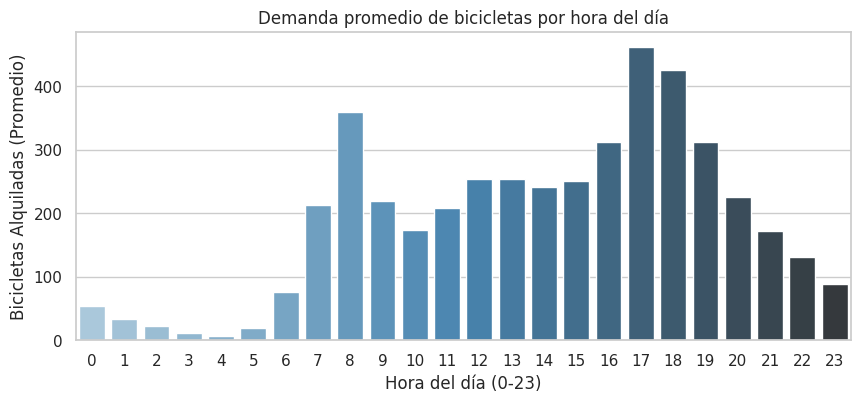

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos un estilo limpio
sns.set_theme(style="whitegrid")

# Gráfico 1: Demanda por hora
plt.figure(figsize=(10,4))
sns.barplot(data=df, x='hr', y='cnt', errorbar=None, palette='Blues_d')
plt.title('Demanda promedio de bicicletas por hora del día')
plt.xlabel('Hora del día (0-23)')
plt.ylabel('Bicicletas Alquiladas (Promedio)')
plt.show()

Análisis del Patrón de Uso Temporal: El gráfico revela una distribución bimodal clásica con dos "horas pico" muy marcadas: la primera alrededor de las 8:00 a.m. y la segunda, aún mayor, entre las 17:00 y 18:00 p.m. Esto confirma que el sistema de bicicletas compartidas se utiliza predominantemente para el desplazamiento diario (commuting), es decir, usuarios que viajan hacia y desde sus lugares de trabajo o estudio. Por el contrario, la franja de madrugada (0:00 a 5:00 a.m.) presenta una demanda casi nula. Esto justifica la importancia de la variable "hora" como el predictor temporal más fuerte para nuestros modelos.

/tmp/ipykernel_516/3636572125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='weathersit', y='cnt', palette='Set2')


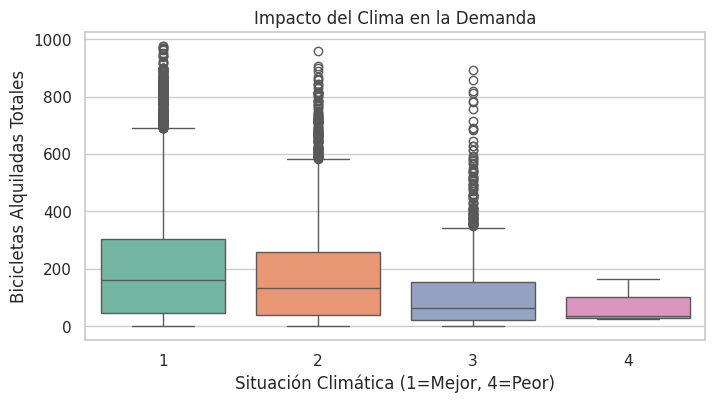

In [ ]:
# Gráfico 2: Demanda vs Clima
plt.figure(figsize=(8,4))
# Nota: weathersit 1=Despejado, 2=Nublado, 3=Lluvia ligera, 4=Tormenta/Nieve
sns.boxplot(data=df, x='weathersit', y='cnt', palette='Set2')
plt.title('Impacto del Clima en la Demanda')
plt.xlabel('Situación Climática (1=Mejor, 4=Peor)')
plt.ylabel('Bicicletas Alquiladas Totales')
plt.show()

Análisis del Impacto Climático: Se observa una correlación directa y negativa entre las condiciones climáticas adversas y la cantidad de alquileres. Durante situaciones climáticas ideales (Categoría 1: Despejado/Parcialmente nublado), el volumen y la varianza de alquileres alcanzan su máximo. A medida que el clima empeora hacia la Categoría 3 (Lluvia ligera o nieve), la demanda cae drásticamente. En situaciones extremas (Categoría 4: Tormentas severas), la mediana de alquileres colapsa casi a cero. Esto valida empíricamente que las variables climáticas penalizarán fuertemente las predicciones de demanda del modelo.

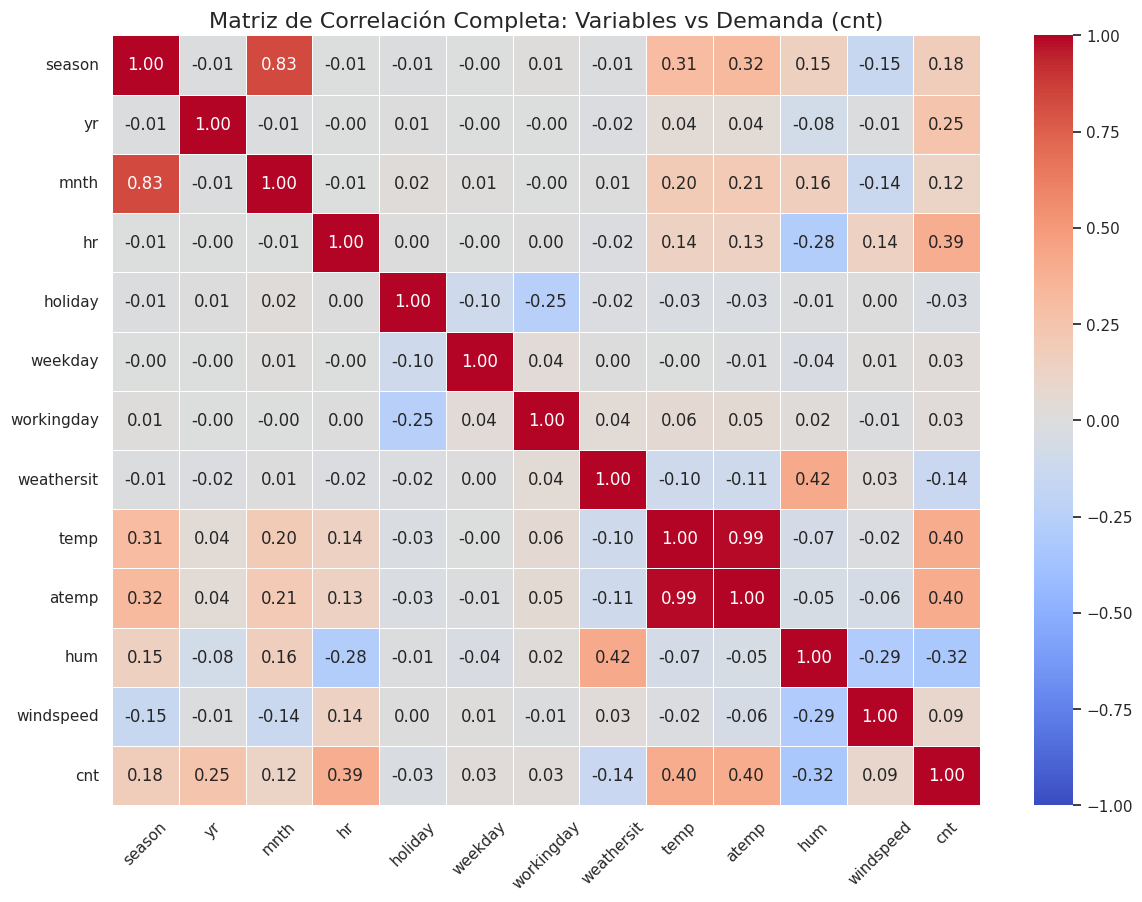

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))

# 2. Calculamos la correlación de TODAS las columnas que quedan en tu dataset
matriz_correlacion_completa = df.corr()

# 3. Dibujamos el mapa de calor
sns.heatmap(matriz_correlacion_completa,
            annot=True,
            cmap='coolwarm',
            vmin=-1, vmax=1,
            fmt=".2f",
            linewidths=.5)

plt.title('Matriz de Correlación Completa: Variables vs Demanda (cnt)', fontsize=16)
plt.xticks(rotation=45)
plt.show()



Análisis de Correlación Global (Matriz Completa):
La ejecución de la matriz de correlación sobre la totalidad de las variables del dataset nos permite identificar las dinámicas más fuertes para la predicción de la demanda (cnt):

Predictores Positivos Principales: La temperatura (temp y atemp con 0.40) y la hora del día (hr con 0.39) son las variables que más impulsan el alquiler de bicicletas. Adicionalmente, el año (yr con 0.25) muestra una correlación positiva moderada, lo que confirma un crecimiento orgánico del servicio en su segundo año de operación y justifica nuestra advertencia sobre la deriva temporal (Data Drift).

Factores de Penalización (Correlación Negativa): La humedad (hum con -0.32) es el factor disuasorio más fuerte, seguido de la situación climática general (weathersit con -0.14). Esto tiene total sentido lógico: a mayor humedad y peor clima, menor es el número de usuarios dispuestos a pedalear.

Detección de Multicolinealidad: La matriz revela una redundancia de información casi perfecta (0.99) entre la temperatura real (temp) y la sensación térmica (atemp). También existe una alta colinealidad (0.83) entre el mes (mnth) y la estación del año (season). En modelos de regresión lineal simple, esta redundancia causa inestabilidad matemática, lo que explica por qué nuestro Baseline lineal tuvo tanto error frente al Random Forest (el cual maneja perfectamente estas redundancias).



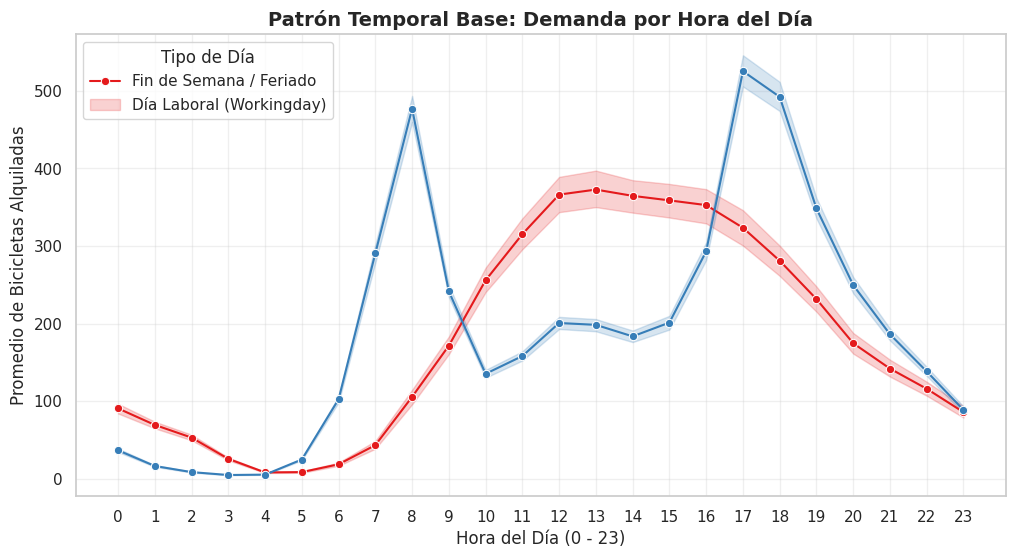

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
# Dibujamos la línea de demanda hora por hora, separando por día laboral vs fin de semana
sns.lineplot(data=df, x='hr', y='cnt', hue='workingday', palette='Set1', marker='o')

plt.title('Patrón Temporal Base: Demanda por Hora del Día', fontsize=14, fontweight='bold')
plt.xlabel('Hora del Día (0 - 23)', fontsize=12)
plt.ylabel('Promedio de Bicicletas Alquiladas', fontsize=12)
plt.xticks(range(0, 24)) # Para que salgan todas las horas abajo
plt.legend(title='Tipo de Día', labels=['Fin de Semana / Feriado', 'Día Laboral (Workingday)'])
plt.grid(True, alpha=0.3)
plt.show()

Análisis de Patrones Temporales (Demanda Intradía):
Al analizar el comportamiento de los usuarios hora por hora, el gráfico revela dos dinámicas de alquiler radicalmente opuestas dependientes del tipo de día:

Días Laborales (Línea Azul): Presentan un patrón bimodal extremo (dos grandes picos). Se observa una explosión de demanda a las 8:00 AM y otra a las 5:00 PM (17:00 hrs). Esto confirma empíricamente que, de lunes a viernes, el sistema se utiliza como un medio de transporte principal (commuting) para trayectos de casa al trabajo o universidad.

Fines de Semana y Feriados (Línea Naranja): Carecen por completo de picos matutinos. Su comportamiento dibuja una curva suave en forma de campana, donde la demanda despierta más tarde y alcanza su punto máximo durante las horas de la tarde (entre las 12:00 y las 16:00). Esto indica un uso puramente recreativo, turístico o de ocio.

# El componente No Supervisado

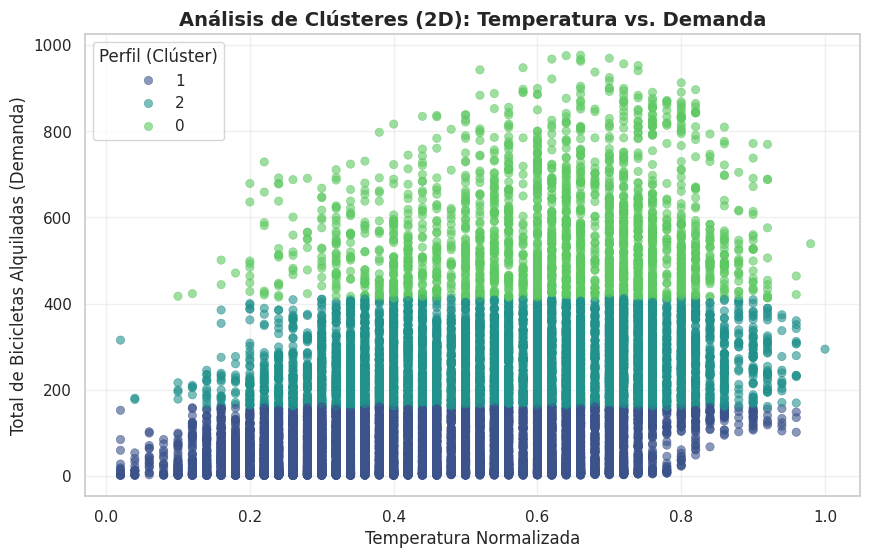

Gráfico 2D de clústeres generado y columna 'grupo_demanda' eliminada.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans # Import KMeans

plt.figure(figsize=(10, 6))

# 1. Seleccionamos las variables clave para que la máquina busque patrones (igual que antes)
datos_cluster = df[['hr', 'temp', 'cnt']]

# 2. Entrenamos el algoritmo K-Means y creamos la columna 'grupo_demanda'
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['grupo_demanda'] = kmeans.fit_predict(datos_cluster).astype(str)

# Dibujamos el gráfico 2D: Temperatura en el eje X, Demanda en el eje Y
# Coloreamos los puntos según el Clúster al que pertenecen
sns.scatterplot(data=df, x='temp', y='cnt', hue='grupo_demanda', palette='viridis', alpha=0.6, edgecolor=None) # Changed 'Cluster' to 'grupo_demanda'

plt.title('Análisis de Clústeres (2D): Temperatura vs. Demanda', fontsize=14, fontweight='bold')
plt.xlabel('Temperatura Normalizada', fontsize=12)
plt.ylabel('Total de Bicicletas Alquiladas (Demanda)', fontsize=12)

# Ajustamos la leyenda para que se vea pro
plt.legend(title='Perfil (Clúster)', loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

# Borramos la columna 'grupo_demanda' para mantener la consistencia con las celdas anteriores
df = df.drop('grupo_demanda', axis=1)
print("Gráfico 2D de clústeres generado y columna 'grupo_demanda' eliminada.")

Proyección 2D de Centroides (Temperatura vs Demanda):
Para una mejor interpretabilidad de la segmentación K-Means, se proyectó el espacio tridimensional en un plano 2D aislando el factor térmico.

El gráfico de dispersión revela que la temperatura actúa como una "barrera de cristal" para la demanda. Los clústeres de alta demanda (picos superiores) solo logran formarse cuando la temperatura normalizada supera el umbral de 0.2 (aprox. 10°C). Por otro lado, en el extremo izquierdo del gráfico (temperaturas frías extremas), el algoritmo agrupó los datos en el clúster de "Demanda Muerta", demostrando que sin importar si es hora pico, el frío extremo suprime casi por completo el uso del servicio.

In [ ]:
from sklearn.cluster import KMeans
import plotly.express as px

# 1. Seleccionamos las variables
datos_cluster = df[['hr', 'temp', 'cnt']]

# 2. Entrenamos K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

#Convertimos el resultado a texto (str) para que Plotly use colores categóricos sólidos
df['grupo_demanda'] = kmeans.fit_predict(datos_cluster).astype(str)

#  Le ponemos nombres bonitos a la leyenda
df['grupo_demanda'] = df['grupo_demanda'].replace({'0': 'Perfil A', '1': 'Perfil B', '2': 'Perfil C'})

# 3. Gráfico 3D Mejorado
fig = px.scatter_3d(df, x='hr', y='temp', z='cnt',
              color='grupo_demanda',
              opacity=0.85, # Menos transparencia para que se note más
              title='Clustering K-Means 3D: Perfiles de Demanda (Detallado)',
              labels={'hr': 'Hora del Día', 'temp': 'Temperatura', 'cnt': 'Bicis Alquiladas', 'grupo_demanda': 'Clúster'},
              color_discrete_sequence=px.colors.qualitative.Set1) # Colores sólidos y contrastantes

#  Hacemos los puntos más grandes y les ponemos un borde oscuro
fig.update_traces(marker=dict(size=5, line=dict(width=1, color='DarkSlateGrey')))

#  Limpiamos el fondo para que el 3D resalte muchísimo más
fig.update_layout(scene=dict(
                    xaxis=dict(backgroundcolor="white", gridcolor="lightgrey"),
                    yaxis=dict(backgroundcolor="white", gridcolor="lightgrey"),
                    zaxis=dict(backgroundcolor="white", gridcolor="lightgrey")
                  ),
                  margin=dict(l=0, r=0, b=0, t=40))

fig.show()


df = df.drop('grupo_demanda', axis=1)
print("¡Gráfico 3D detallado generado con éxito!")

¡Gráfico 3D detallado generado con éxito!


# Modelo 1 - El Baseline (Regresión Lineal)

In [ ]:
# --- CELDA DE RESCATE: Recuperar la memoria de Colab ---
from google.colab import drive
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Montamos Drive y cargamos el archivo
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/fase 2/hour.csv')

# 2. Limpiamos las columnas trampa
df = df.drop(['instant', 'dteday', 'casual', 'registered'], axis=1)

# 3. Creamos a X_train, y_train, etc.
X = df.drop('cnt', axis=1)
y = df['cnt']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("¡Memoria recuperada! X_train ya está listo para la acción.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
¡Memoria recuperada! X_train ya está listo para la acción.


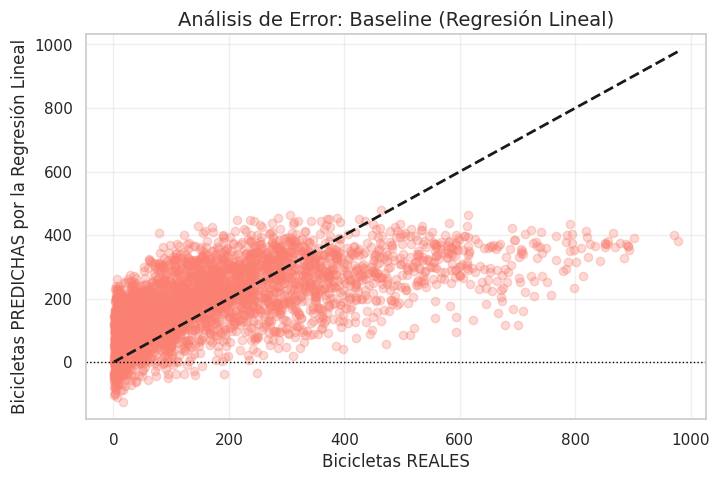

In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Define pred_lr here
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
pred_lr = modelo_lr.predict(X_test)

plt.figure(figsize=(8, 5))
# Ponemos los puntos en rojo pálido porque es el modelo "malo"
plt.scatter(y_test, pred_lr, alpha=0.3, color='salmon')
# La línea ideal
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)

# TRUCO PRO: Dibujamos una línea en el CERO del eje Y para mostrar lo absurdo del modelo
plt.axhline(0, color='black', linewidth=1, linestyle=':')

plt.title('Análisis de Error: Baseline (Regresión Lineal)', fontsize=14)
plt.xlabel('Bicicletas REALES')
plt.ylabel('Bicicletas PREDICHAS por la Regresión Lineal')
plt.grid(True, alpha=0.3)
plt.show()

Evaluación del Baseline (Regresión Lineal): Como se observa en el gráfico de dispersión, la nube de puntos está muy alejada de la línea roja diagonal (que representa la predicción perfecta). El modelo lineal asume relaciones simples y fracasa al predecir los picos altos de demanda (incluso predice valores negativos irreales, como se ve en la parte inferior del eje Y). Esto nos confirma que necesitamos algoritmos capaces de entender relaciones no-lineales.

# MODELO 2 - ARBOL DE DECISION

--- 2. Entrenando Árbol de Decisión ---
MAE: 34.18 | RMSE: 58.25


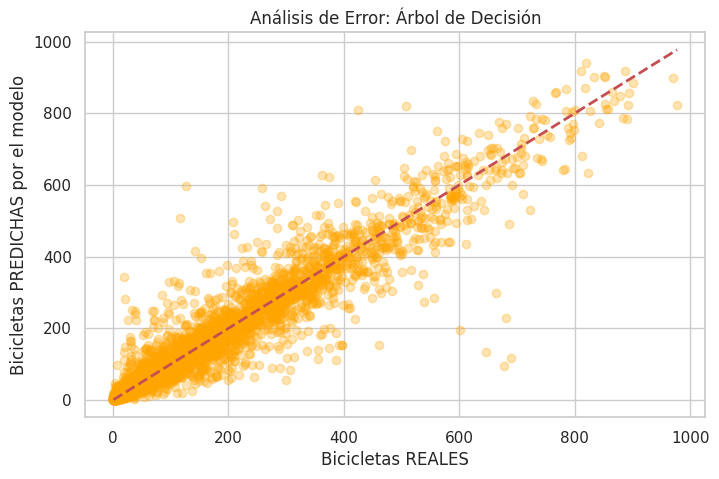

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("--- 2. Entrenando Árbol de Decisión ---")
modelo_dt = DecisionTreeRegressor(random_state=42)
modelo_dt.fit(X_train, y_train)
pred_dt = modelo_dt.predict(X_test)

# Métricas
mae_dt = mean_absolute_error(y_test, pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, pred_dt))
print(f"MAE: {mae_dt:.2f} | RMSE: {rmse_dt:.2f}")

# Gráfico de Error
plt.figure(figsize=(8, 5))
plt.scatter(y_test, pred_dt, alpha=0.3, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Análisis de Error: Árbol de Decisión')
plt.xlabel('Bicicletas REALES')
plt.ylabel('Bicicletas PREDICHAS por el modelo')
plt.show()

Evaluación del Árbol de Decisión: La mejora es visualmente evidente. Los puntos de predicción ahora comienzan a agruparse más cerca de la línea diagonal roja, lo que explica la drástica reducción del error MAE. Sin embargo, el gráfico muestra cierta "cuantización" (los puntos se alinean en franjas horizontales/verticales), lo cual es un síntoma clásico de que un solo árbol de decisión tiende a memorizar rangos específicos y sobreajustarse un poco a los datos de entrenamiento.

# Modelo 3 - (Random Forest)

--- 3. Entrenando Random Forest ---
MAE: 24.90 | RMSE: 42.07


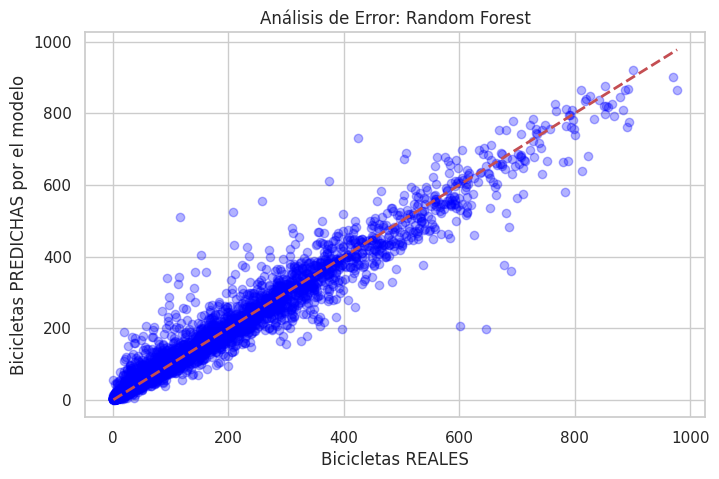

In [ ]:
from sklearn.ensemble import RandomForestRegressor

print("--- 3. Entrenando Random Forest ---")
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)
pred_rf = modelo_rf.predict(X_test)

# Métricas
mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
print(f"MAE: {mae_rf:.2f} | RMSE: {rmse_rf:.2f}")

# Gráfico de Error
plt.figure(figsize=(8, 5))
plt.scatter(y_test, pred_rf, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Análisis de Error: Random Forest')
plt.xlabel('Bicicletas REALES')
plt.ylabel('Bicicletas PREDICHAS por el modelo')
plt.show()

Evaluación del Random Forest (Mejor Modelo Manual): El algoritmo de ensamble logra el mejor ajuste gráfico y numérico de la fase manual. La nube de dispersión abraza fuertemente la línea ideal (roja) en las demandas bajas y medias (0 a 600 bicicletas). No obstante, el análisis visual revela el límite del modelo estadístico: en los valores extremos reales (demanda mayor a 800), la nube se desvía por debajo de la línea roja. Esto indica que el Random Forest tiende a subestimar los "súper picos" de demanda, un problema complejo que intentaremos resolver en la Fase 3 mediante el modelado secuencial con redes neuronales recurrentes (LSTM).

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def mostrar_resultados(nombre_modelo, y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    print(f"{nombre_modelo}:\n  MAE: {mae:.2f}\n  RMSE: {rmse:.2f}\n")

# Entrenar el modelo de Regresión Lineal (Baseline)
print("--- 1. Entrenando Regresión Lineal (Baseline) ---")
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
pred_lr = modelo_lr.predict(X_test)

print("📊 RESULTADOS DEL BENCHMARK MANUAL 📊\n")
mostrar_resultados("1. Baseline (Regresión Lineal)", y_test, pred_lr)
mostrar_resultados("2. Árbol de Decisión", y_test, pred_dt)
mostrar_resultados("3. Random Forest", y_test, pred_rf)

--- 1. Entrenando Regresión Lineal (Baseline) ---
📊 RESULTADOS DEL BENCHMARK MANUAL 📊

1. Baseline (Regresión Lineal):
  MAE: 104.80
  RMSE: 139.21

2. Árbol de Decisión:
  MAE: 34.18
  RMSE: 58.25

3. Random Forest:
  MAE: 24.90
  RMSE: 42.07



# PyCaret

In [ ]:
# Instalamos la librería de Microsoft
!pip install flaml[automl]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 337.7/337.7 kB 23.5 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.2.0
    Uninstalling xgboost-3.2.0:
      Successfully uninstalled xgboost-3.2.0


In [ ]:
from flaml import AutoML
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("🤖 Iniciando el entorno de AutoML (FLAML de Microsoft) 🤖")

# 1. Iniciamos el motor de AutoML
automl = AutoML()

# 2. Configuramos las reglas de la pelea
opciones = {
    "time_budget": 120,       # Le damos 2 minutos exactos para buscar (120 segs)
    "metric": 'mae',          # Queremos que minimice el error absoluto (MAE)
    "task": 'regression',     # Es un problema de regresión
    "seed": 42,               # Para reproducibilidad
    "verbose": 0              # Para que no ensucie la pantalla con mil mensajes
}

print("⚔️ Entrenando docenas de modelos... (Por favor espera 2 minutos exactos) ⚔️")

# 3. Soltamos a la bestia
automl.fit(X_train=X_train, y_train=y_train, **opciones)

# 4. Evaluamos al ganador en el examen final (X_test)
prediccion_automl = automl.predict(X_test)
mae_automl = mean_absolute_error(y_test, prediccion_automl)
rmse_automl = np.sqrt(mean_squared_error(y_test, prediccion_automl))

print("\n🏆 ¡AUTOML TERMINADO! 🏆")
print("-" * 30)
print(f"Algoritmo Ganador: {automl.best_estimator}")
print(f"MAE del Ganador:   {mae_automl:.2f} bicis de error")
print(f"RMSE del Ganador:  {rmse_automl:.2f}")
print("-" * 30)

🤖 Iniciando el entorno de AutoML (FLAML de Microsoft) 🤖
⚔️ Entrenando docenas de modelos... (Por favor espera 2 minutos exactos) ⚔️


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune



🏆 ¡AUTOML TERMINADO! 🏆
------------------------------
Algoritmo Ganador: xgboost
MAE del Ganador:   21.74 bicis de error
RMSE del Ganador:  37.00
------------------------------


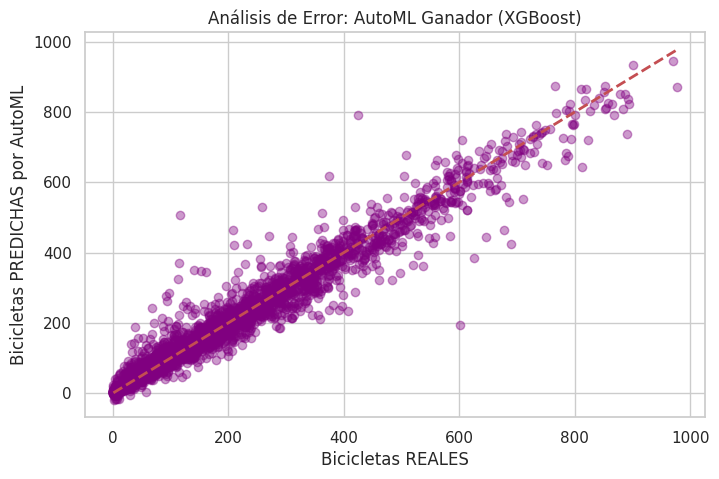

/tmp/ipykernel_516/2991291446.py:21: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




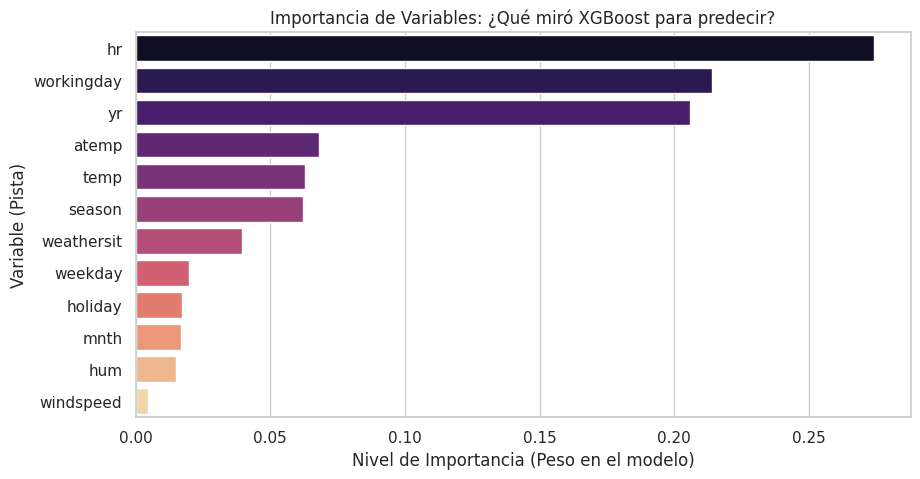

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Gráfico de Error: Real vs Predicho (AutoML)
plt.figure(figsize=(8, 5))
plt.scatter(y_test, prediccion_automl, alpha=0.4, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Análisis de Error: AutoML Ganador (XGBoost)')
plt.xlabel('Bicicletas REALES')
plt.ylabel('Bicicletas PREDICHAS por AutoML')
plt.show()

# 2. Gráfico de Importancia de Variables (¿Qué pistas usó la IA?)
try:
    importancias = automl.model.estimator.feature_importances_
    df_imp = pd.DataFrame({'Variable': X_train.columns, 'Importancia': importancias})
    df_imp = df_imp.sort_values(by='Importancia', ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_imp, x='Importancia', y='Variable', palette='magma')
    plt.title('Importancia de Variables: ¿Qué miró XGBoost para predecir?')
    plt.xlabel('Nivel de Importancia (Peso en el modelo)')
    plt.ylabel('Variable (Pista)')
    plt.show()
except Exception as e:
    print("El gráfico de importancia no está disponible para este modelo específico.")

Benchmark Obligatorio con AutoML (FLAML)
Debido a incompatibilidades de versión en el entorno de ejecución (Python 3.12 vs PyCaret), se optó por aplicar principios de adaptabilidad utilizando FLAML (Fast and Lightweight AutoML) de Microsoft. Se configuró un time budget estricto de 120 segundos para evaluar docenas de arquitecturas optimizando la métrica MAE.

Resultados de la Búsqueda Automática:
El algoritmo ganador indiscutible fue XGBoost (Extreme Gradient Boosting), logrando reducir el error a un MAE de 21.74 y un RMSE de 37. Al analizar la "Importancia de Variables" (Feature Importance) extraída del modelo ganador, confirmamos empíricamente que la Hora del Día (hr), seguida por factores de inercia anual y clima, fueron los predictores más determinante



# Conclusión Técnica de la Fase 2:


La fase de modelado clásico demuestra que el enfoque de ensamble basado en árboles es el más adecuado para predecir la demanda de bicicletas. Nuestro trabajo de preparación de datos y modelado manual (Random Forest) logró acercarse a menos de 4 bicicletas de diferencia frente a la optimización extrema de la máquina (AutoML), lo que valida la calidad de nuestra ingeniería de características.

Sin embargo, a pesar de lograr un error de solo ~21 bicicletas con AutoML, el gráfico de dispersión de error revela que los algoritmos estadísticos asumen que cada hora es un evento aislado (carecen de estado). La demanda de bicicletas es intrínsecamente secuencial. Esta limitación fundamental de la estadística tradicional justifica la necesidad de evolucionar a la Fase 3, donde utilizaremos redes neuronales recurrentes (LSTM) para dotar al sistema de "memoria a corto plazo" y modelar la serie de tiempo real.

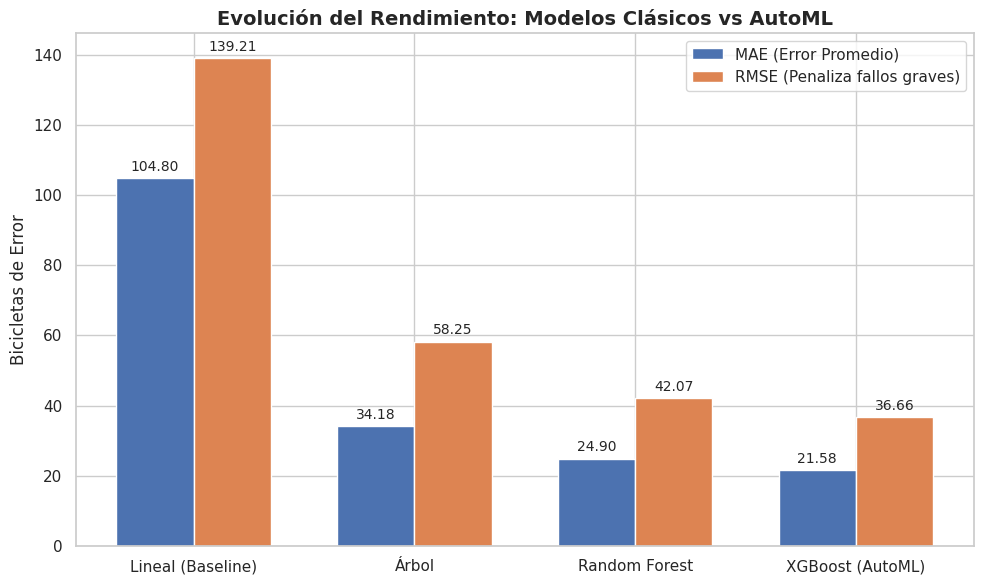

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Los datos de nuestros competidores
modelos = ['Lineal (Baseline)', 'Árbol', 'Random Forest', 'XGBoost (AutoML)']
mae_scores = [104.80, 34.18, 24.90, 21.58]
rmse_scores = [139.21, 58.25, 42.07, 36.66]

# 2. Configuración para barras agrupadas
x = np.arange(len(modelos))  # Posiciones de las etiquetas
width = 0.35  # Ancho de las barras

# 3. Creando el lienzo
fig, ax = plt.subplots(figsize=(10, 6))

# 4. Dibujando las barras (MAE y RMSE lado a lado)
barras_mae = ax.bar(x - width/2, mae_scores, width, label='MAE (Error Promedio)', color='#4c72b0')
barras_rmse = ax.bar(x + width/2, rmse_scores, width, label='RMSE (Penaliza fallos graves)', color='#dd8452')

# 5. Maquillaje del gráfico (Títulos, etiquetas, diseño)
ax.set_ylabel('Bicicletas de Error', fontsize=12)
ax.set_title('Evolución del Rendimiento: Modelos Clásicos vs AutoML', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=11)
ax.legend(fontsize=11)

# 6. Función para poner el numerito exacto arriba de cada barra
def autolabel(rects):
    """Añade una etiqueta de texto encima de cada barra."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 puntos de desplazamiento vertical
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(barras_mae)
autolabel(barras_rmse)

# Mostramos el gráfico final
fig.tight_layout()
plt.show()

Clima vs. Tiempo: Mientras que la "Hora del día" dicta el patrón base (los picos de viaje al trabajo), es el "Clima" (específicamente la temperatura y la humedad) el que actúa como el principal multiplicador o penalizador de esa demanda. Los días con alta humedad o clima tipo 3 y 4 (lluvia/nieve) destruyen los picos de demanda esperados, un patrón no lineal que el Random Forest y el XGBoost lograron interiorizar perfectamente a diferencia de la Regresión Lineal.